In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub
path = kagglehub.dataset_download("adrianmcmahon/imdb-india-movies")
print("path to dataset files:",path)

Using Colab cache for faster access to the 'imdb-india-movies' dataset.
path to dataset files: /kaggle/input/imdb-india-movies


In [ ]:
import os
print(os.listdir(path))

['IMDb Movies India.csv']


In [ ]:
import pandas as pd
file_path = os.path.join(path,"IMDb Movies India.csv")
data = pd.read_csv(file_path,encoding="latin1")
print(data.head())

                                 Name    Year Duration            Genre  \
0                                         NaN      NaN            Drama   
1  #Gadhvi (He thought he was Gandhi)  (2019)  109 min            Drama   
2                         #Homecoming  (2021)   90 min   Drama, Musical   
3                             #Yaaram  (2019)  110 min  Comedy, Romance   
4                   ...And Once Again  (2010)  105 min            Drama   

   Rating Votes            Director       Actor 1             Actor 2  \
0     NaN   NaN       J.S. Randhawa      Manmauji              Birbal   
1     7.0     8       Gaurav Bakshi  Rasika Dugal      Vivek Ghamande   
2     NaN   NaN  Soumyajit Majumdar  Sayani Gupta   Plabita Borthakur   
3     4.4    35          Ovais Khan       Prateik          Ishita Raj   
4     NaN   NaN        Amol Palekar  Rajat Kapoor  Rituparna Sengupta   

           Actor 3  
0  Rajendra Bhatia  
1    Arvind Jangid  
2       Roy Angana  
3  Siddhant Kapoor  
4    

In [ ]:
print(data.shape)
print(data.columns)
print(data.info())

(15509, 10)
Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB
None


In [ ]:
print(data.isnull().sum())

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64


In [ ]:
data = data.dropna(subset=["Rating"])
data["Year"] = data["Year"].str.extract(r"(\d{4})").astype(float)
data["Votes"] = data["Votes"].str.replace(",","",regex=False).astype(float)
print(data.shape)
print(data[["Year","Votes","Rating" ]].head())

(7919, 10)
     Year   Votes  Rating
1  2019.0     8.0     7.0
3  2019.0    35.0     4.4
5  1997.0   827.0     4.7
6  2005.0  1086.0     7.4
8  2012.0   326.0     5.6


In [ ]:
print(data.isnull().sum())

Name           0
Year           0
Duration    2068
Genre        102
Rating         0
Votes          0
Director       5
Actor 1      125
Actor 2      200
Actor 3      292
dtype: int64


In [ ]:
data["Duration"] = data["Duration"].str.extract(r"(\d+)").astype(float)
data["Duration"] = data["Duration"].fillna(data["Duration"].median())
data["Genre"] = data["Genre"].fillna("Unknown")
data["Director"] = data["Director"].fillna("Unknown")
data["Actor 1"] = data["Actor 1"].fillna("Unknown")
data["Actor 2"] = data["Actor 2"].fillna("Unknown")
data["Actor 3"] = data["Actor 3"].fillna("Unknown")
print(data.isnull().sum())

Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64


In [ ]:
x = data[["Year","Duration","Votes"]]
y = data["Rating"]
print(x.head())
print(y.head())

     Year  Duration   Votes
1  2019.0     109.0     8.0
3  2019.0     110.0    35.0
5  1997.0     147.0   827.0
6  2005.0     142.0  1086.0
8  2012.0      82.0   326.0
1    7.0
3    4.4
5    4.7
6    7.4
8    5.6
Name: Rating, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x , y, test_size=0.2,random_state=42)
print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (6335, 3)
Testing data: (1584, 3)


In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)
print("Model training completed successfully!")

Model training completed successfully!


In [ ]:
y_pred = model.predict(x_test)
print(y_pred[:10])

[5.81710528 5.52234607 5.463633   5.69587977 5.55472348 5.70140655
 5.96220451 5.60150124 6.2089061  5.81000329]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:",r2)

Mean Absolute Error: 1.048120146209968
Mean Squared Error: 1.7226438538086775
R2 Score: 0.07342153328958656


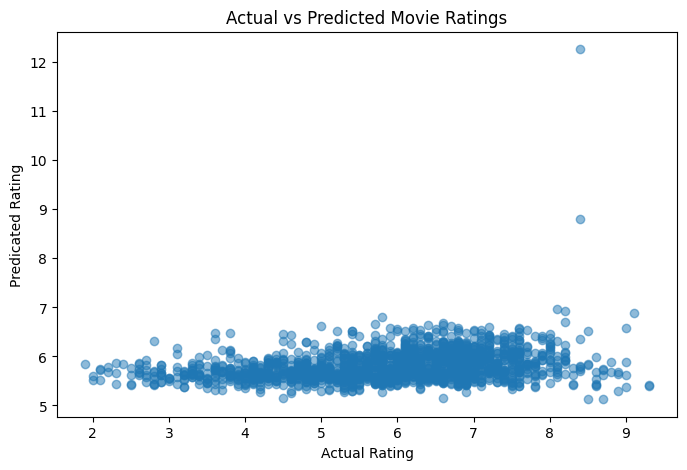

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred,alpha=0.5)
plt.xlabel("Actual Rating")
plt.ylabel("Predicated Rating")
plt.title("Actual vs Predicted Movie Ratings")
plt.show()

In [ ]:
print(data.columns.tolist())

['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3', 'Genre_Frequency', 'Genre_Frequency_Frequency']


In [ ]:
!pip install scikit-learn

In [ ]:
import sklearn
print(sklearn.__version__)
print(sklearn.__file__)
from sklearn.preprocessing import OneHotEncoder
print("OneHotEncoder imported successfully")

1.6.1
/usr/local/lib/python3.12/dist-packages/sklearn/__init__.py
OneHotEncoder imported successfully


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_transformer
from sklearn.linear_model import LinearRegression
data= data.copy()
data.columns = data.columns.str.strip().str.lower()
x = data[["year","duration","votes","genre","director","actor 1","actor 2","actor 3"]].copy()
y = data["rating"]
x["year"] = x["year"].astype(float)
x["duration"] = x["duration"].astype(float)
x["votes"] = x["votes"].astype(float)
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
numeric_features = ["year","duration", "votes"]
categorical_features = ["genre","director","actor 1","actor 2","actor 3"]
preprocessor = ColumnTransformer(transformers=[("num","passthrough",numeric_features),("cat",OneHotEncoder(handle_unknown="ignore"),categorical_features)])
print("Improved model training ccompleted sucessfully")

Improved model training ccompleted sucessfully
